<a href="https://colab.research.google.com/github/cse2023210012-prog/Student-Social-Media-And-Mental-Health-Impact-training-/blob/main/Student_Social_Media_And_Mental_Health_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [64]:
#df = pd.read_csv('Student Social Media And Mental Health Impact.csv')
url = 'https://raw.githubusercontent.com/cse2023210012-prog/Student-Social-Media-And-Mental-Health-Impact-training-/main/Student%20Social%20Media%20And%20Mental%20Health%20Impact.csv'

df = pd.read_csv(url)

In [65]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [66]:
# Detect missing values
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [67]:
# Count total duplicate rows
df.duplicated().sum()

np.int64(2)

In [68]:
# Drop duplicate rows (keeps first by default)
df = df.drop_duplicates()

In [69]:
# Remove outliers using Z-Score
from scipy import stats

# Select specific columns
cols = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]

# Calculate Z-scores, check if absolute value < 3, and ensure ALL selected columns satisfy the condition
df_clean = df[
    (np.abs(stats.zscore(df[cols], nan_policy="omit")) < 3).all(axis=1)
]

Training Random Forest Classifier...

Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Classification Report (Random Forest):

              precision    recall  f1-score   support

        Fair       0.94      0.95      0.95       722
        Good       0.89      0.87      0.88       255
        Poor       0.67      0.43      0.53        23

    accuracy                           0.92      1000
   macro avg       0.83      0.75      0.78      1000
weighted avg       0.92      0.92      0.92      1000



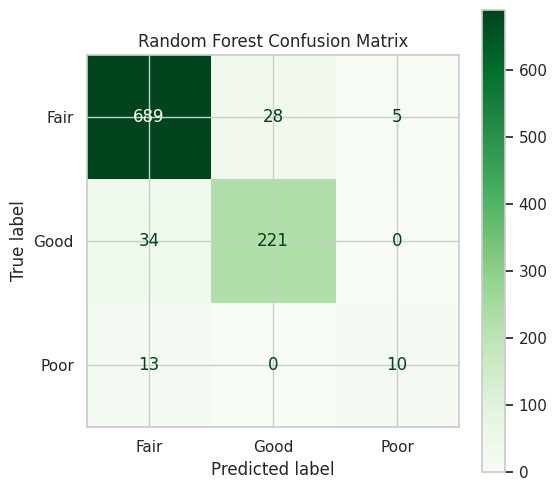

In [70]:
# =========================================================
# AOM Vilimel : RANDOM FOREST CLASSIFIER
# =========================================================

# IMPORTS
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# PREPROCESSING & FEATURE ENGINEERING
# Bin Mental_Health_Score into 3 risk categories
bins = [0, 4, 7, 10]
labels = ['Poor', 'Fair', 'Good']
df['Mental_Health_Category'] = pd.cut(df['Mental_Health_Score'], bins=bins, labels=labels)
df = df.dropna(subset=['Mental_Health_Category'])

# Encode target categories into numbers (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(df['Mental_Health_Category'])

# Separate features (X) and drop targets to prevent data leakage
X_raw = df.drop(columns=['Mental_Health_Score', 'Mental_Health_Category', 'Stress_Level'], errors='ignore')

# One-Hot Encode categorical/text columns
X = pd.get_dummies(X_raw, drop_first=True)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# HYPERPARAMETER TUNING WITH GRIDSEARCHCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("Training Random Forest Classifier...")
rf_grid.fit(X_train, y_train)

# EVALUATION
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nBest Parameters Found:", rf_grid.best_params_)
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# VISUALIZATION (CONFUSION MATRIX)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=le.classes_, ax=ax, cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()



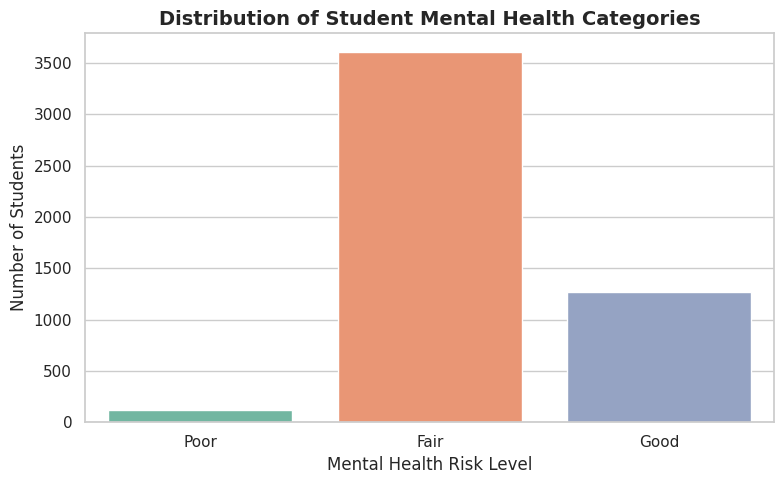

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 1. Distribution of Mental Health Risk Levels (Target Variable)
sns.countplot(x="Mental_Health_Category", data=df, palette="Set2")
plt.title(
    "Distribution of Student Mental Health Categories",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Mental Health Risk Level", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.tight_layout()
plt.show()

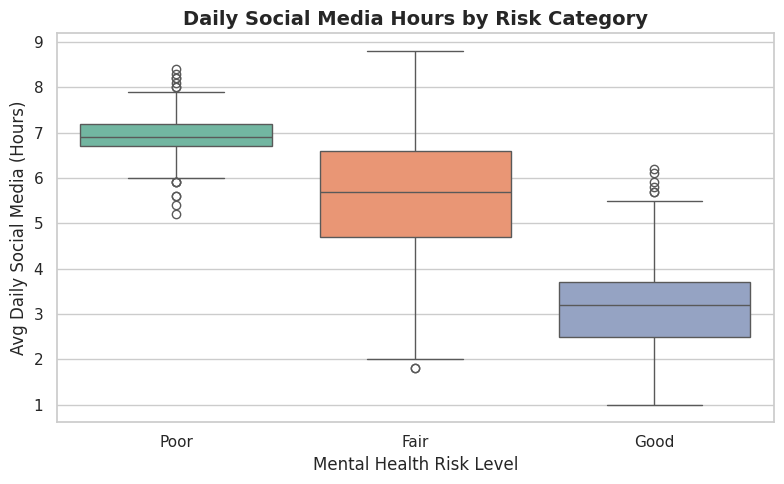

In [72]:
plt.figure(figsize=(8, 5))

# 2. Daily Social Media Usage vs. Mental Health Risk
sns.boxplot(
    x="Mental_Health_Category",
    y="Avg_Daily_Usage_Hours",
    data=df,
    palette="Set2",
)
plt.title(
    "Daily Social Media Hours by Risk Category", fontsize=14, fontweight="bold"
)
plt.xlabel("Mental Health Risk Level", fontsize=12)
plt.ylabel("Avg Daily Social Media (Hours)", fontsize=12)

plt.tight_layout()
plt.show()

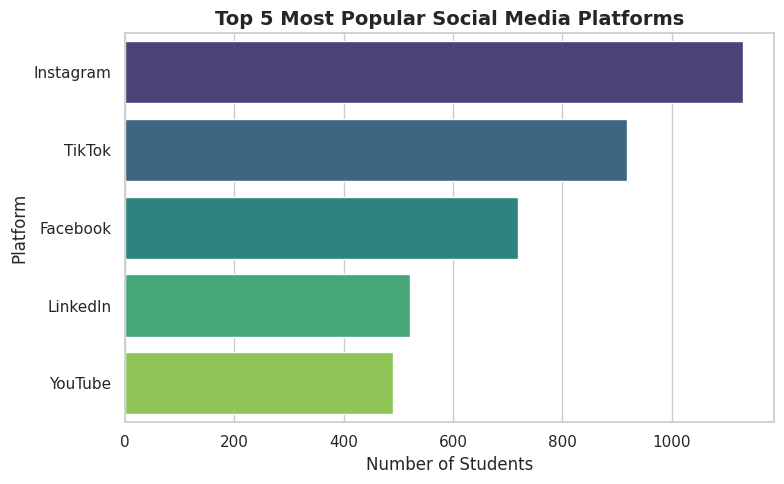

In [73]:
plt.figure(figsize=(8, 5))

# 4. Most Used Social Media Platforms
top_platforms = df["Most_Used_Platform"].value_counts().head(5)
sns.barplot(
    x=top_platforms.values, y=top_platforms.index, palette="viridis"
)
plt.title(
    "Top 5 Most Popular Social Media Platforms", fontsize=14, fontweight="bold"
)
plt.xlabel("Number of Students", fontsize=12)
plt.ylabel("Platform", fontsize=12)

plt.tight_layout()
plt.show()

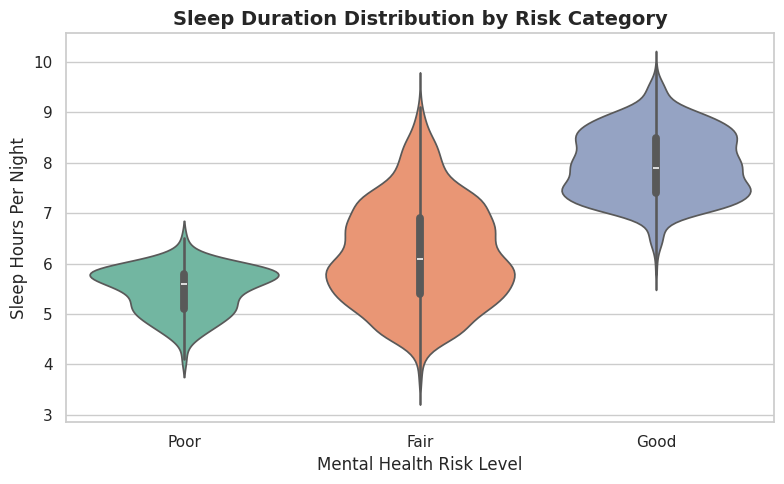

In [74]:
plt.figure(figsize=(8, 5))

# 3. Sleep Hours vs. Mental Health Risk
sns.violinplot(
    x="Mental_Health_Category",
    y="Sleep_Hours_Per_Night",
    data=df,
    palette="Set2",
)
plt.title(
    "Sleep Duration Distribution by Risk Category",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Mental Health Risk Level", fontsize=12)
plt.ylabel("Sleep Hours Per Night", fontsize=12)

plt.tight_layout()
plt.show()